# Tableau Plots in Python - mpl and plotly

In [36]:
# Libraries
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#data
csv_orders_url = 'https://raw.githubusercontent.com/dupadhyaya/piit/refs/heads/main/data/superstore_orders.csv'
orders = pd.read_csv(csv_orders_url)
orders.shape

(9994, 21)

In [4]:
df = orders.copy()
df.shape

(9994, 21)

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
# Clean dates
df["Order Date"] = pd.to_datetime(df["Order Date"], format='%Y-%m-%d')
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format='%Y-%m-%d')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## Bar Plot - Tableau
- Tableau 
    - Region - Columns
    - Sales - Row : Sum(Sales)

In [12]:
region_sales = ( df.groupby("Region")["Sales"].sum().sort_values(ascending=False))
region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

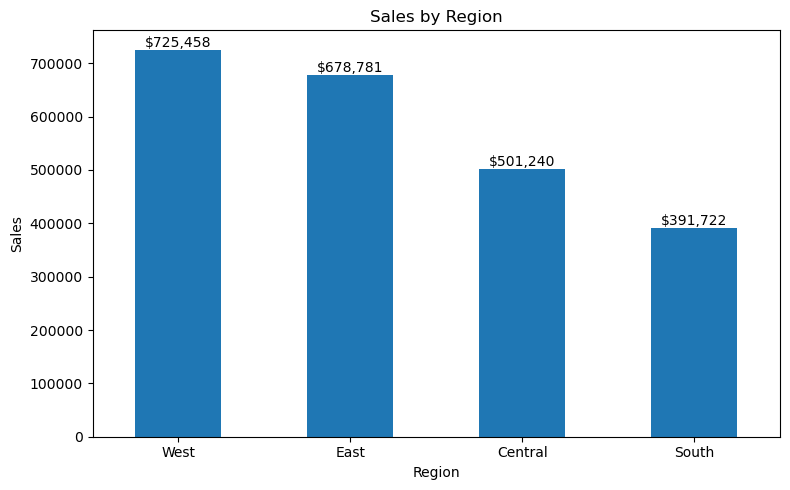

In [13]:
# mpl
ax = region_sales.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}", (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",      va="bottom"   )
plt.tight_layout()
plt.show();

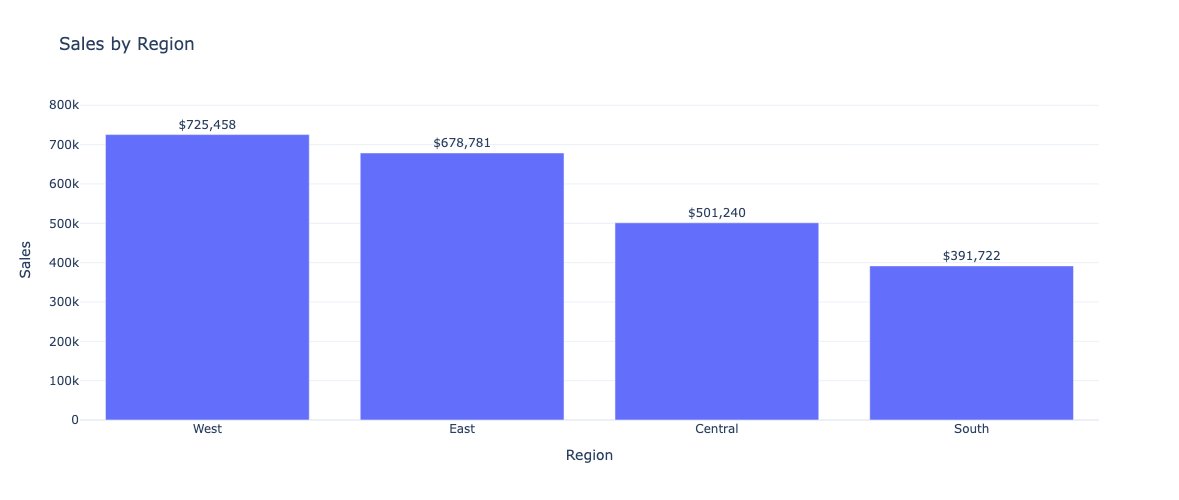

In [15]:
# Plotly
region_sales_plotly = region_sales.reset_index()
fig = px.bar( region_sales_plotly, x="Region", y="Sales",text="Sales", title="Sales by Region"
)
fig.update_traces(texttemplate="$%{text:,.0f}",  textposition="outside")
fig.update_layout(template="plotly_white", width=800, height=500)
fig.show();

## Horizontal Bar Chart : Top 10 Customers
- Tableau 
    - Rows - Customer Name
    - Columns - Sales : Sum (sales)
    - Sort - Descending on Sum(sales)
    - Filter - Top 10 on Customer Name by Sum(Sales)

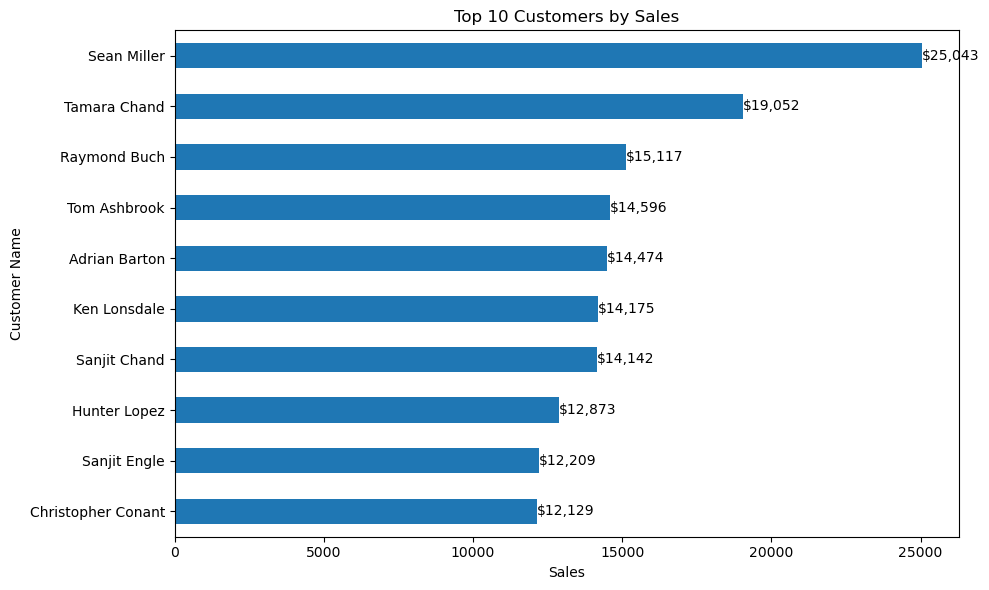

In [16]:
top_customers = (  df.groupby("Customer Name")["Sales"]
      .sum().sort_values(ascending=False).head(10).sort_values())
ax = top_customers.plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer Name")
for p in ax.patches:
    ax.annotate(
        f"${p.get_width():,.0f}",(p.get_width(), p.get_y() + p.get_height()/2),
        ha="left",  va="center" )
plt.tight_layout()
plt.show();

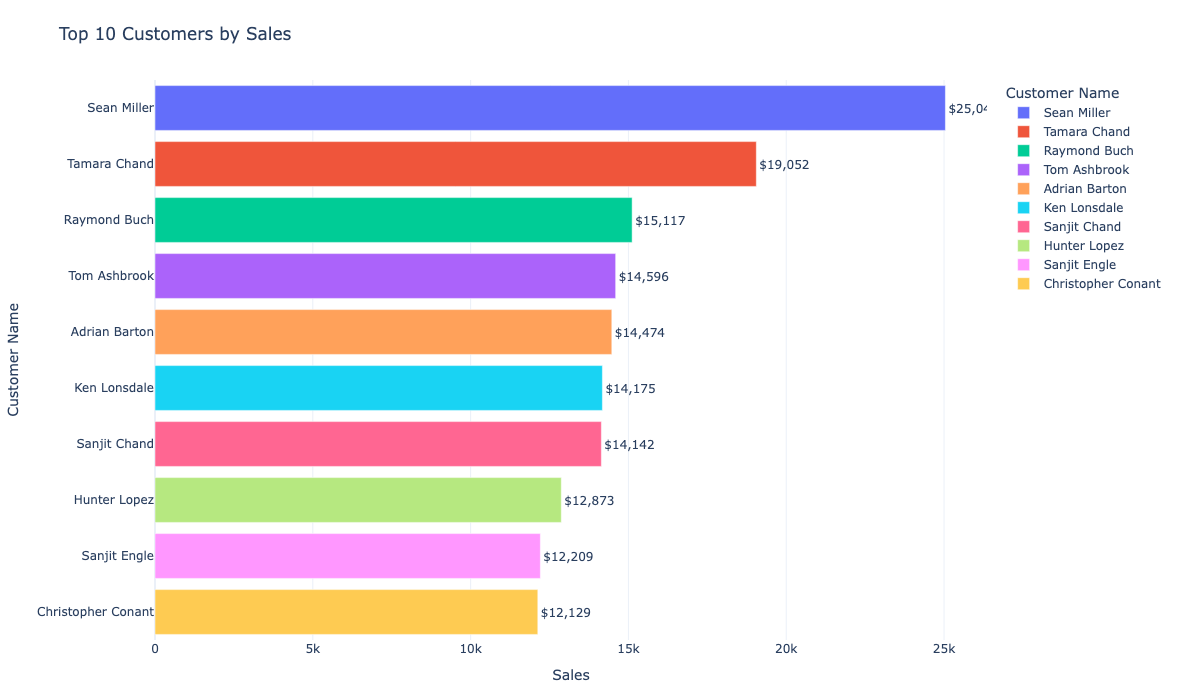

In [19]:
## Plotly
top_customers_plotly = ( df.groupby("Customer Name")["Sales"].sum()
      .reset_index().sort_values("Sales", ascending=False).head(10))
fig = px.bar(top_customers_plotly, x="Sales", y="Customer Name", color='Customer Name', orientation="h",
    text="Sales", title="Top 10 Customers by Sales")
fig.update_traces( texttemplate="$%{text:,.0f}", textposition="outside")
fig.update_layout( template="plotly_white", width=800, height=700, margin=dict(l=100, r=100, t=80, b=60),
   yaxis=dict(categoryorder="total ascending"))
fig.show();

## Line Chart : Monthly Sales Trend
- Tableau
     - Column - Order Date : Year(Order Date) - Month(Order Date)
     - Row - Sales : Sum(Sales)

In [23]:
monthly_sales = (df.set_index("Order Date").resample("ME")["Sales"].sum())
monthly_sales

Order Date
2014-01-31    28953.7060
2014-02-28    12743.1080
2014-03-31    54801.9060
2014-04-30    24710.0160
2014-05-31    29639.8340
2014-06-30    29287.0306
2014-07-31    35341.2460
2014-08-31    37854.5475
2014-09-30    66110.2238
2014-10-31    34561.9470
2014-11-30    64817.6185
2014-12-31    65426.3147
2015-01-31    29347.3864
2015-02-28    20728.3520
2015-03-31    40876.6112
2015-04-30    38056.9685
2015-05-31    30933.7145
2015-06-30    28862.1982
2015-07-31    28730.3760
2015-08-31    50094.5280
2015-09-30    66729.3290
2015-10-31    32025.0750
2015-11-30    50732.3090
2015-12-31    53415.6612
2016-01-31    38048.1840
2016-02-29    49238.4100
2016-03-31    49612.0450
2016-04-30    45192.2780
2016-05-31    64964.3218
2016-06-30    38991.9430
2016-07-31    42773.3950
2016-08-31    46339.9884
2016-09-30    41985.1423
2016-10-31    52268.1500
2016-11-30    66837.5850
2016-12-31    72954.1555
2017-01-31    64734.3110
2017-02-28    50011.4894
2017-03-31    74774.0838
2017-04-30    

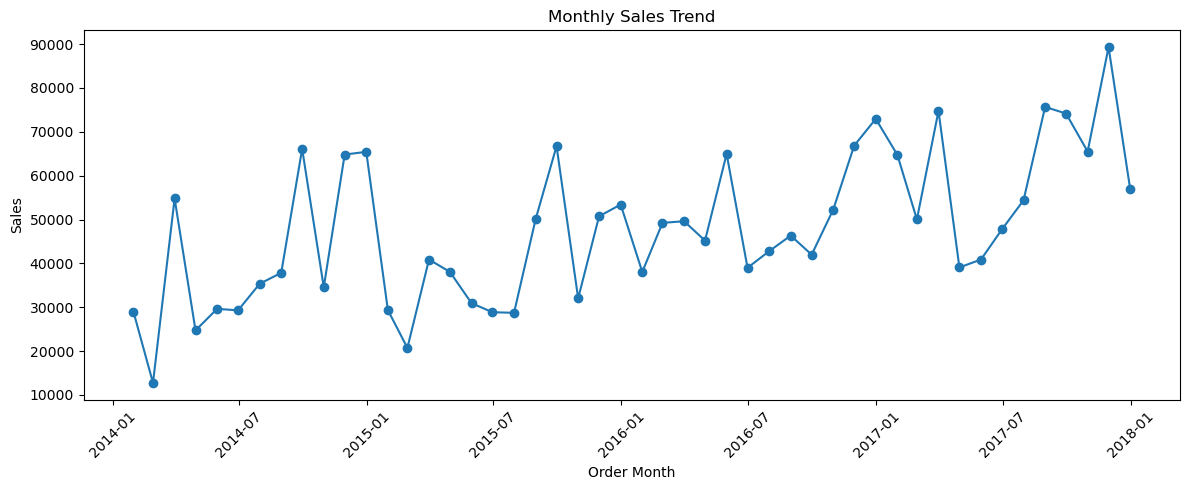

In [21]:
# mpl
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Order Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

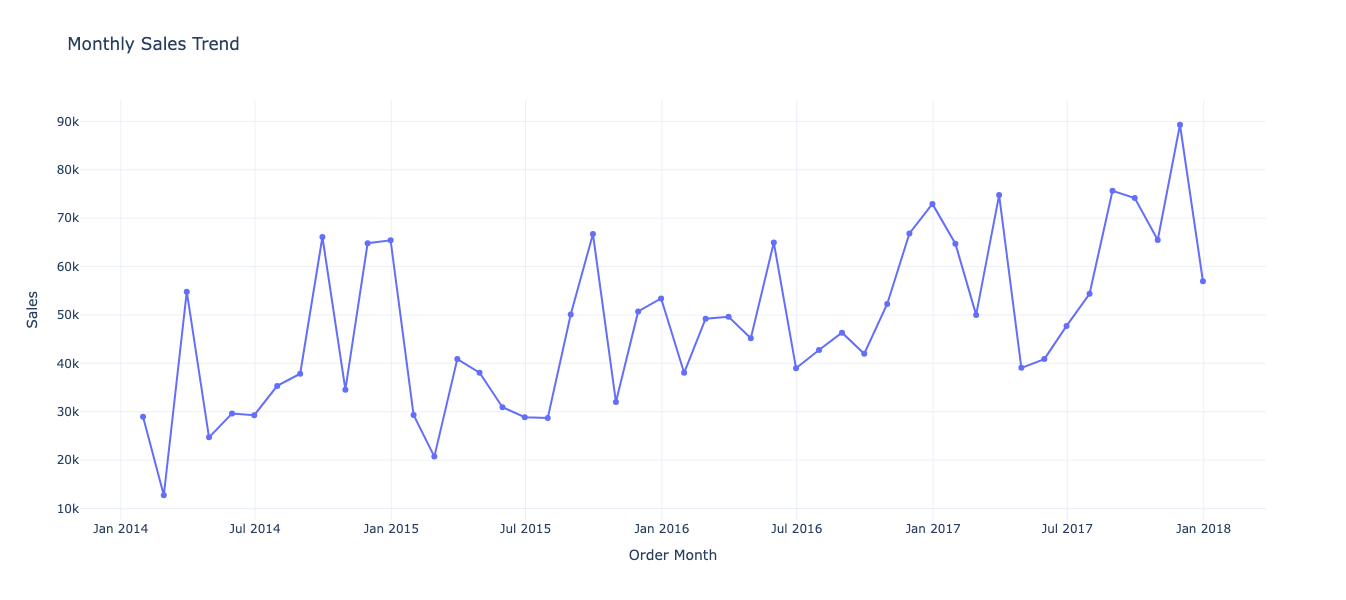

In [22]:
# plotly
monthly_sales_plotly = monthly_sales.reset_index()
monthly_sales_plotly.columns = ["Order Month", "Sales"]
fig = px.line( monthly_sales_plotly, x="Order Month",  y="Sales",  markers=True,
  title="Monthly Sales Trend")
fig.update_layout( template="plotly_white", width=1200,height=600)
fig.show();

In [53]:
## Function - Remove Outliers
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower) &(df[column] <= upper) ]
    return filtered_df

## Histogram : Sales Distribution
- Tableau
    - Column - Sales : Sum(Sales)
    - Create Bins
    - Rows : No of records 

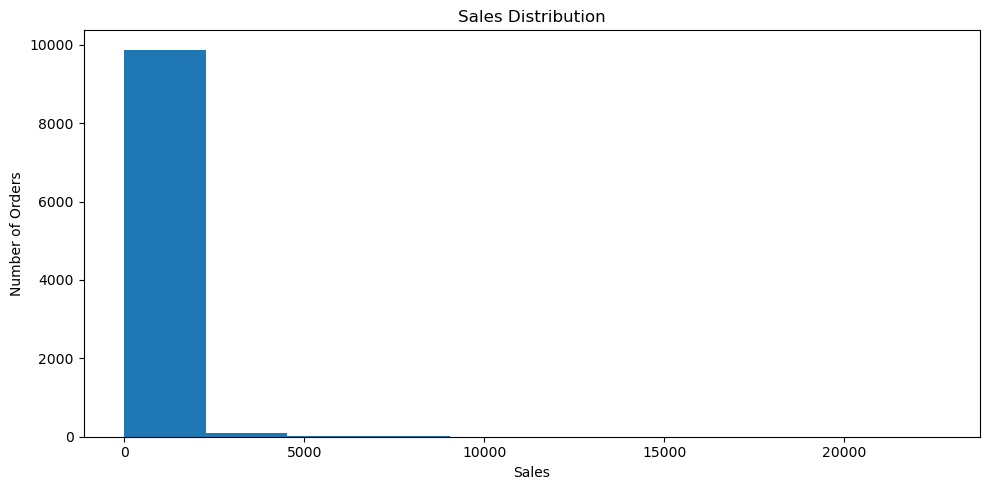

In [26]:
#mpl
plt.figure(figsize=(10,5))
plt.hist(df["Sales"], bins=10)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show();

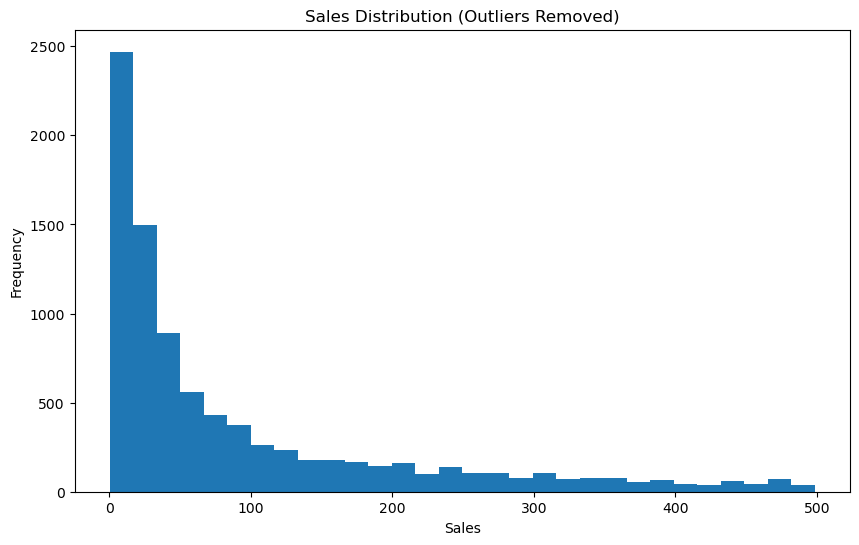

In [54]:
sales_clean = remove_outliers_iqr(df, "Sales")
plt.figure(figsize=(10,6))
plt.hist( sales_clean["Sales"],  bins=30)
plt.title("Sales Distribution (Outliers Removed)")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show();

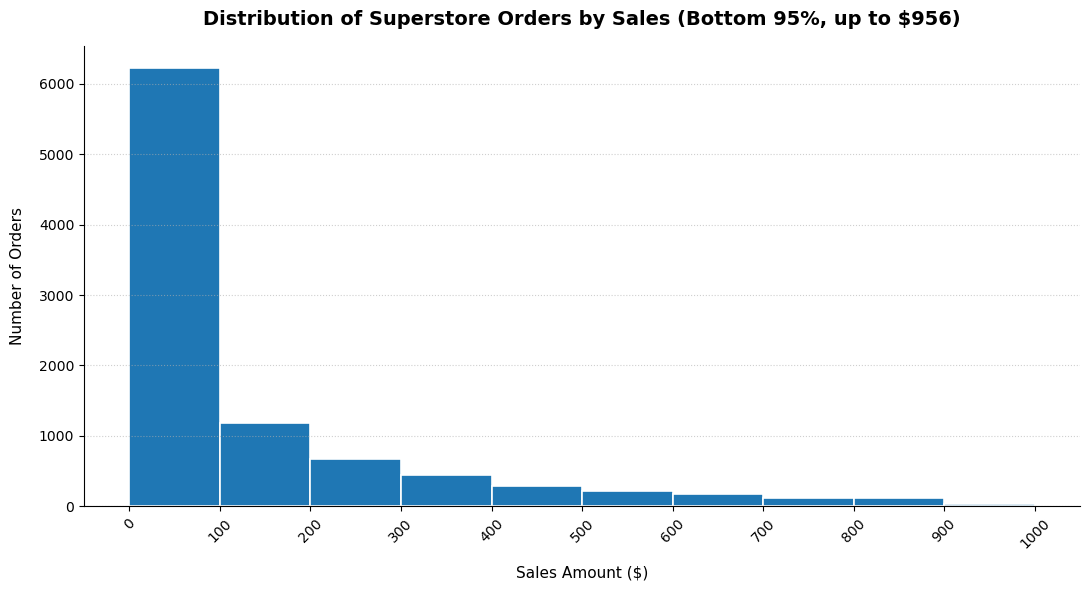

In [27]:
sales_data = df["Sales"]
min_range = 0
max_range = int(sales_data.quantile(0.95))  # Drops the top 5% extreme outliers
bin_width = 100  # Rounded, clean integer step for readable intervals

# Filter out the extreme transactions
filtered_sales = sales_data[(sales_data >= min_range) & (sales_data <= max_range)]
# 4. Generate clean, round-number bin edges
custom_bins = list(range(min_range, max_range + bin_width, bin_width))
# 5. Build and style the Histogram
plt.figure(figsize=(11, 6))

plt.hist(    filtered_sales,    bins=custom_bins,
    color="#1f77b4",  # Classic corporate blue
    edgecolor="#ffffff",  # Crisp white borders to separate bars
    linewidth=1.2,)

# 6. Professional Chart Formatting
plt.title(    f"Distribution of Superstore Orders by Sales (Bottom 95%, up to ${max_range})",
    fontsize=14,    pad=15,    fontweight="bold",
)
plt.xlabel("Sales Amount ($)", fontsize=11, labelpad=10)
plt.ylabel("Number of Orders", fontsize=11, labelpad=10)

# Gridlines & Axis configuration
plt.xticks(custom_bins, rotation=45)  # Rotated labels prevent text overlapping
plt.grid(axis="y", linestyle=":", alpha=0.6)  # Subtle vertical indicators

# Clean layout: remove heavy top and right boundary lines
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

# Render
plt.tight_layout()
plt.show()

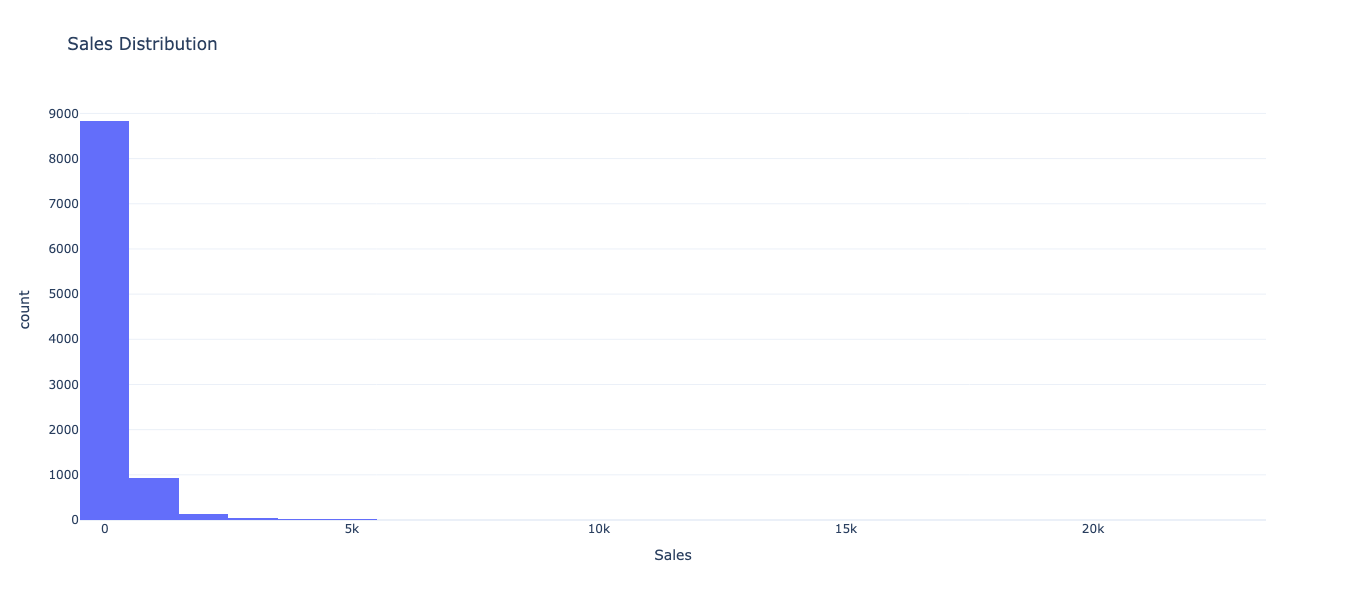

In [25]:
# Plotly
fig = px.histogram(  df, x="Sales", nbins=30, title="Sales Distribution")
fig.update_layout(template="plotly_white",   width=1000, height=600)
fig.show();

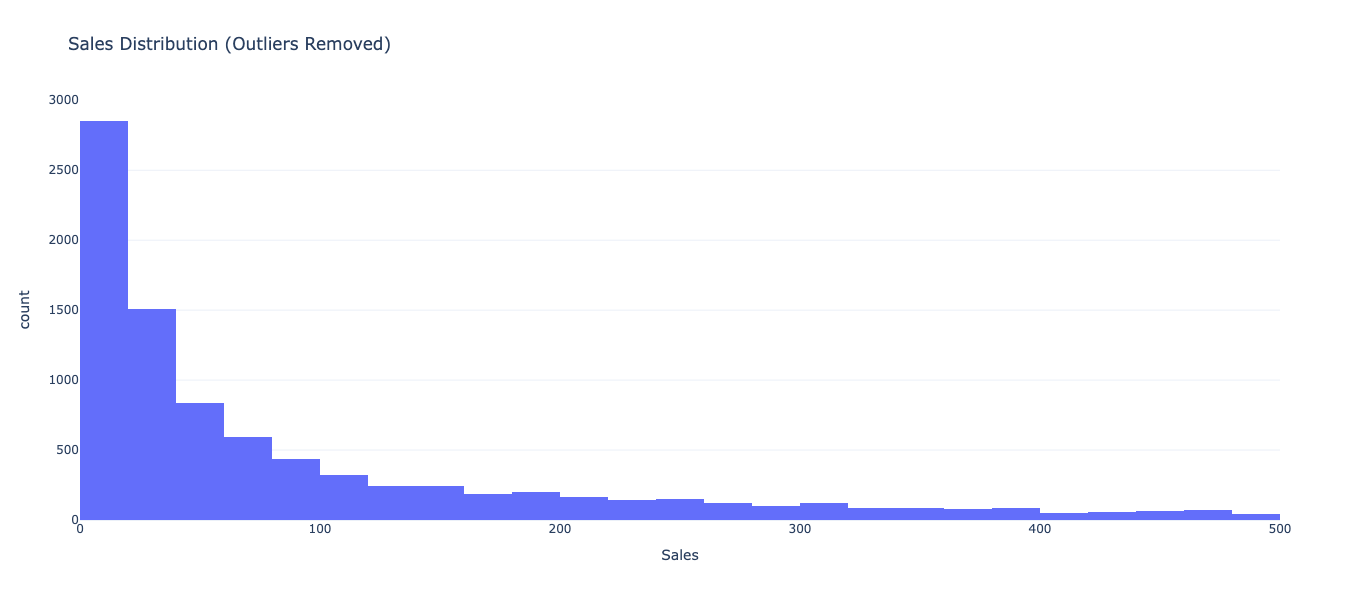

In [55]:
sales_clean = remove_outliers_iqr(df, "Sales")
fig = px.histogram(   sales_clean,  x="Sales",   nbins=30,  title="Sales Distribution (Outliers Removed)")
fig.update_layout(  template="plotly_white",  width=1000,  height=600)
fig.show();

## Teemap : Sales By Category and Sub-Category
- Tableau
    - Marks - Category-> Sub-Category
    - Size - Sales : sum(Sales)


In [72]:
#!pip install squarify
import squarify
treemap_data = (  df.groupby(["Category", "Sub-Category"])["Sales"].sum().reset_index().sort_values("Sales", ascending=False))
treemap_data

,Category,Sub-Category,Sales
16,Technology,Phones,330007.0540
1,Furniture,Chairs,328449.1030
11,Office Supplies,Storage,223843.6080
3,Furniture,Tables,206965.5320
6,Office Supplies,Binders,203412.7330
15,Technology,Machines,189238.6310
13,Technology,Accessories,167380.3180
14,Technology,Copiers,149528.0300
0,Furniture,Bookcases,114879.9963
4,Office Supplies,Appliances,107532.1610


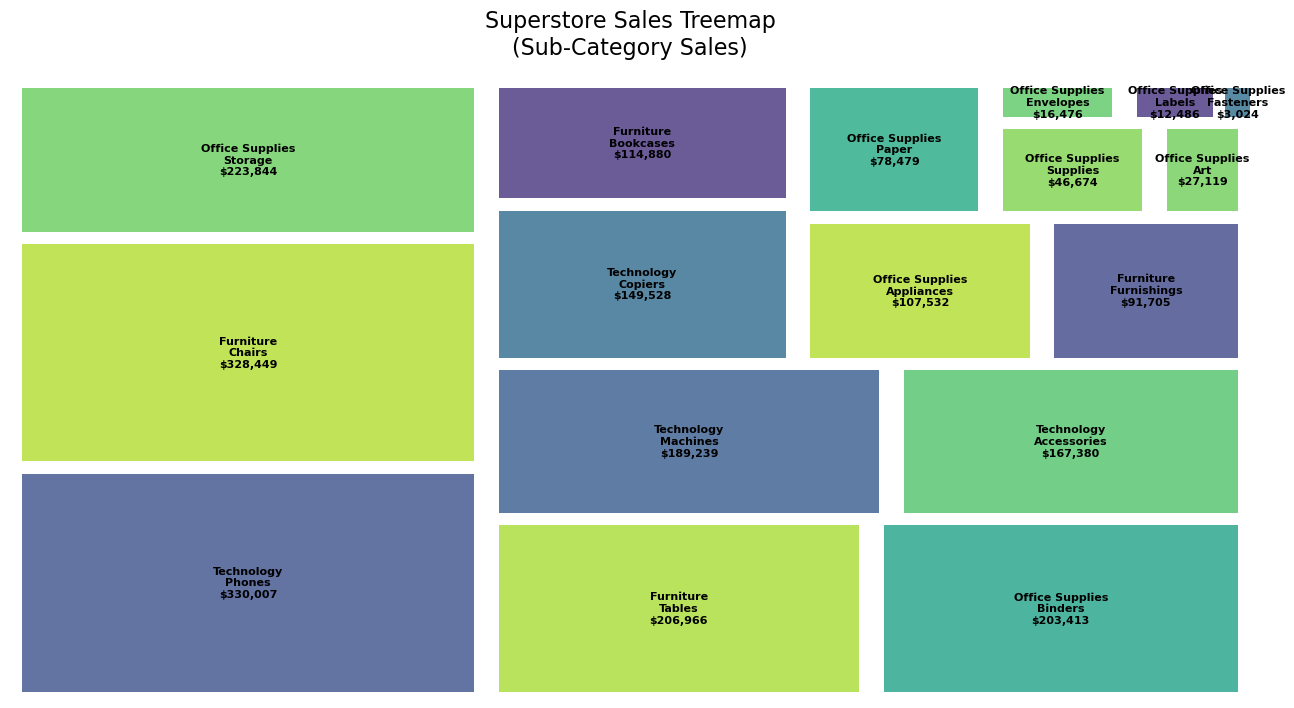

In [71]:
# Create labels
#treemap_data["Label"] = ( treemap_data["Sub-Category"] +   "\n$" + treemap_data["Sales"].round(0).map('{:,.0f}'.format))
treemap_data["Label"] = (    treemap_data["Category"] +   "\n" +   treemap_data["Sub-Category"] +    "\n$" +  treemap_data["Sales"].round(0).map('{:,.0f}'.format))
plt.figure(figsize=(16,8))
squarify.plot(  sizes=treemap_data["Sales"], label=treemap_data["Label"],   alpha=0.8,   pad=True,   text_kwargs={   'fontsize':8, 'weight':'bold'  })
plt.title(   "Superstore Sales Treemap\n(Sub-Category Sales)",   fontsize=16,   pad=20)
plt.axis('off')
plt.show();


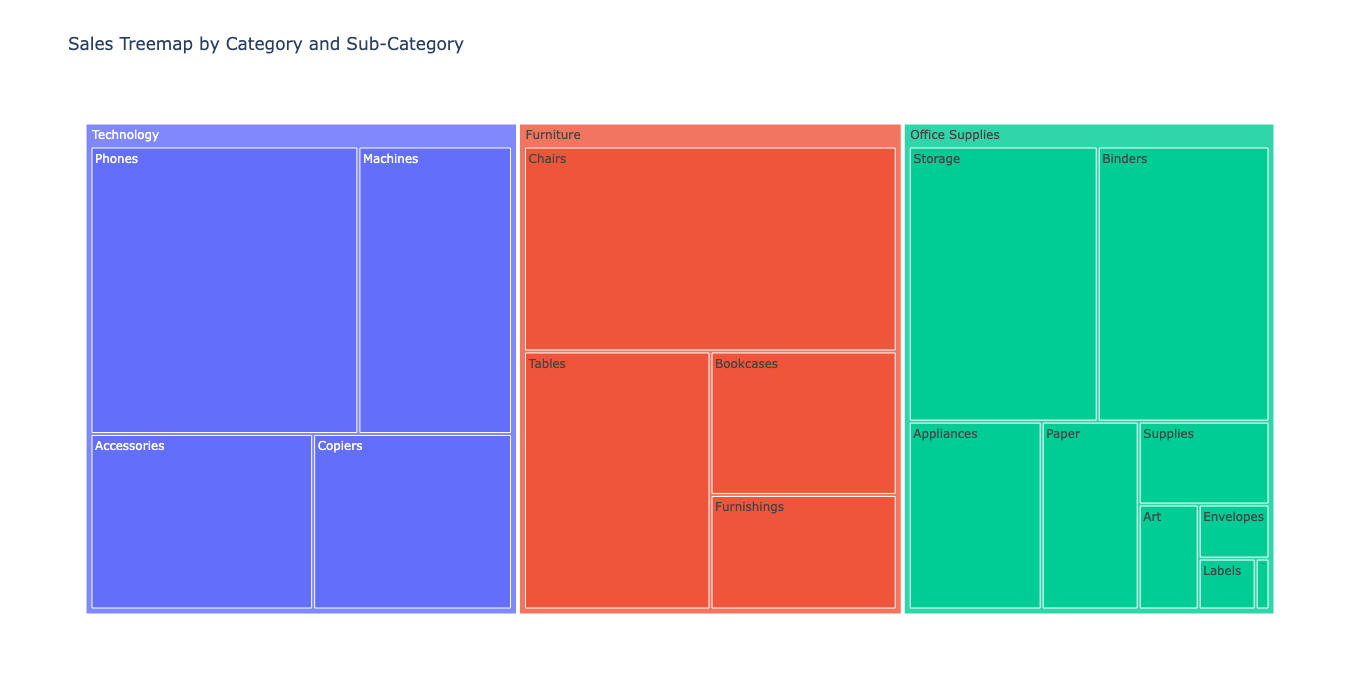

In [28]:
#plotly
fig = px.treemap(  df,  path=["Category", "Sub-Category"], values="Sales", title="Sales Treemap by Category and Sub-Category")
fig.update_layout(    template="plotly_white",  width=1200,  height=700)
fig.show();

## Scatter Plot : Sales vs Profit
- Tableau
    - Columns - Sales
    - Rows - Profit
    - Color Mark - Category 


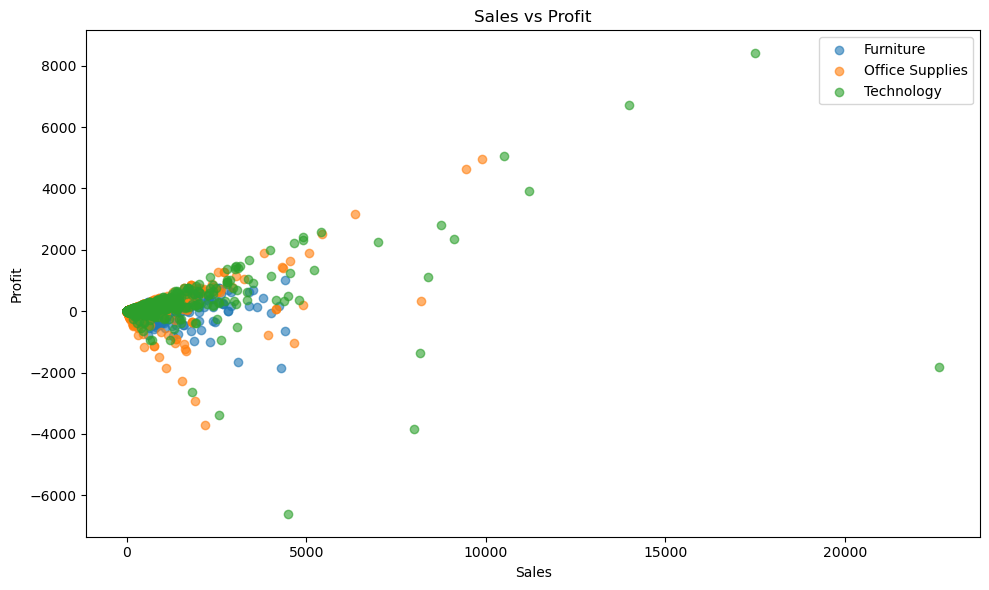

In [29]:
# mpl
plt.figure(figsize=(10,6))
for category in df["Category"].unique(): 
    temp = df[df["Category"] == category]
    plt.scatter(        temp["Sales"],        temp["Profit"],        label=category,        alpha=0.6    )
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.legend()
plt.tight_layout()
plt.show();

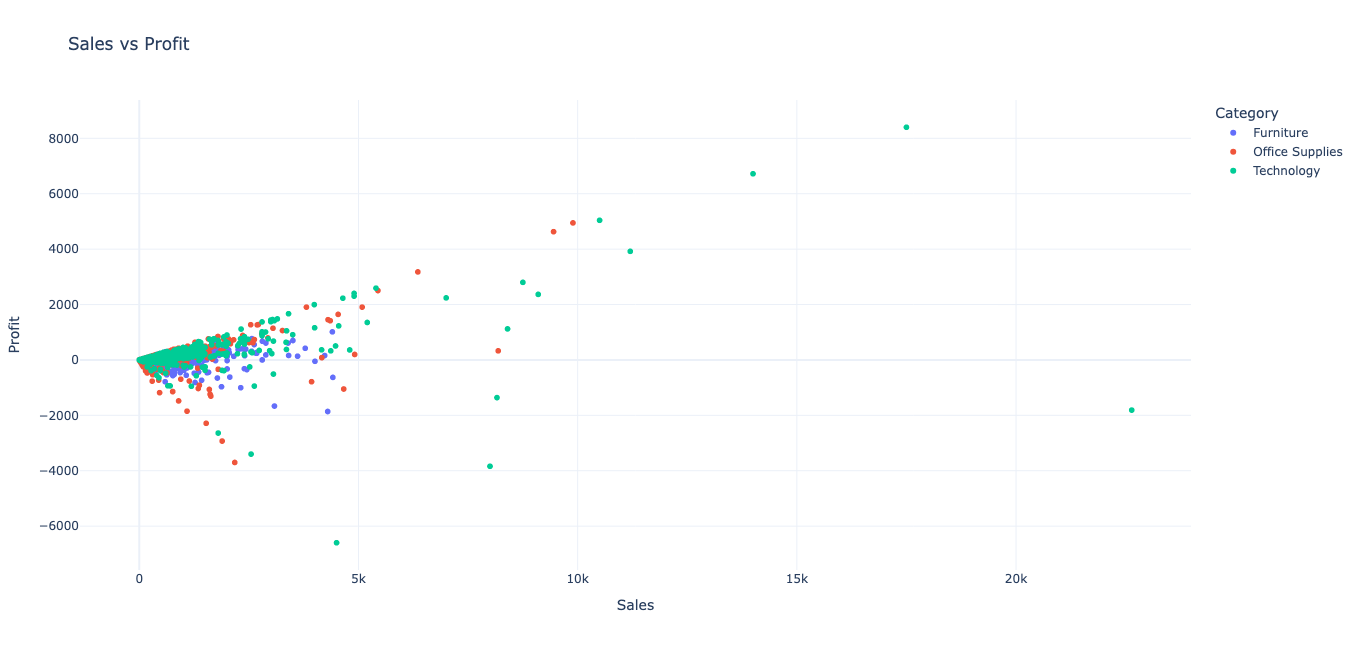

In [30]:
# plotly
fig = px.scatter( df,    x="Sales",    y="Profit",    color="Category",    hover_data=["Customer Name", "Sub-Category", "Region"],    title="Sales vs Profit")
fig.update_layout(  template="plotly_white",   width=1000,   height=650)
fig.show();

## Box Plot : Profit by Category
- Tableau
    - Columns - Category
    - Rows - Profit
    - Show Boxplot
- Plotly
    - https://plotly.com/python/box-plots/ 

In [37]:
categories = df["Category"].unique()
data = [ df[df["Category"] == cat]["Profit"]   for cat in categories]
data

[0        41.9136
 1       219.5820
 3      -383.0310
 5        14.1694
 10       85.3092
           ...   
 9962    -67.6704
 9964      6.4320
 9980     22.3548
 9989      4.1028
 9990     15.6332
 Name: Profit, Length: 2121, dtype: float64,
 2        6.8714
 4        2.5164
 6        1.9656
 8        5.7825
 9       34.4700
          ...   
 9982    16.7132
 9984    15.1200
 9985    16.1240
 9992    13.3200
 9993    72.9480
 Name: Profit, Length: 6026, dtype: float64,
 7        90.7152
 11       68.3568
 19       16.0110
 26       11.7741
 35      123.4737
           ...   
 9983     27.4344
 9986     15.2208
 9987     28.7964
 9988     55.6470
 9991     19.3932
 Name: Profit, Length: 1847, dtype: float64]

/var/folders/z4/8qd93wx14xz1c9qfb_z969wc0000gn/T/ipykernel_39216/2677457422.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=categories)


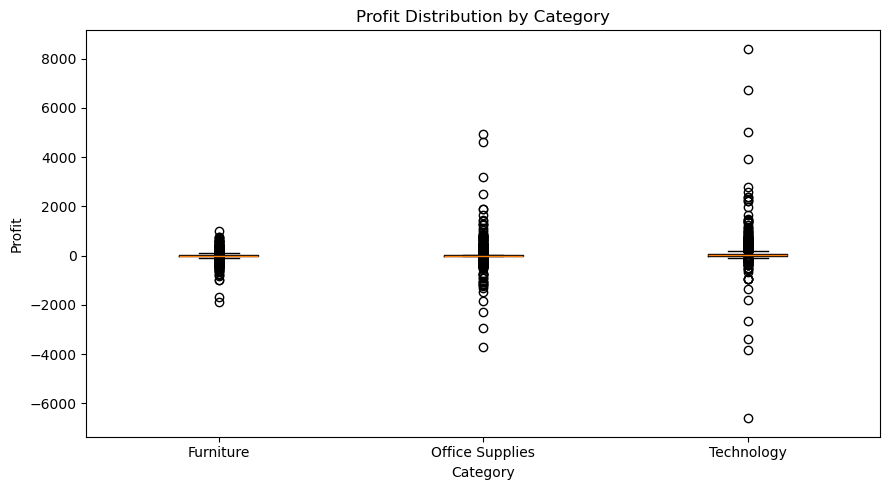

In [38]:
# mpl
plt.figure(figsize=(9,5))
plt.boxplot(data, labels=categories)
plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show();

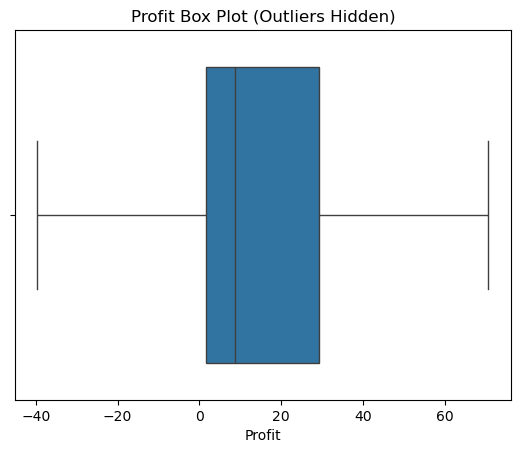

In [39]:
# sns
sns.boxplot(data=df, x='Profit', showfliers=False)
plt.title('Profit Box Plot (Outliers Hidden)')
plt.show()

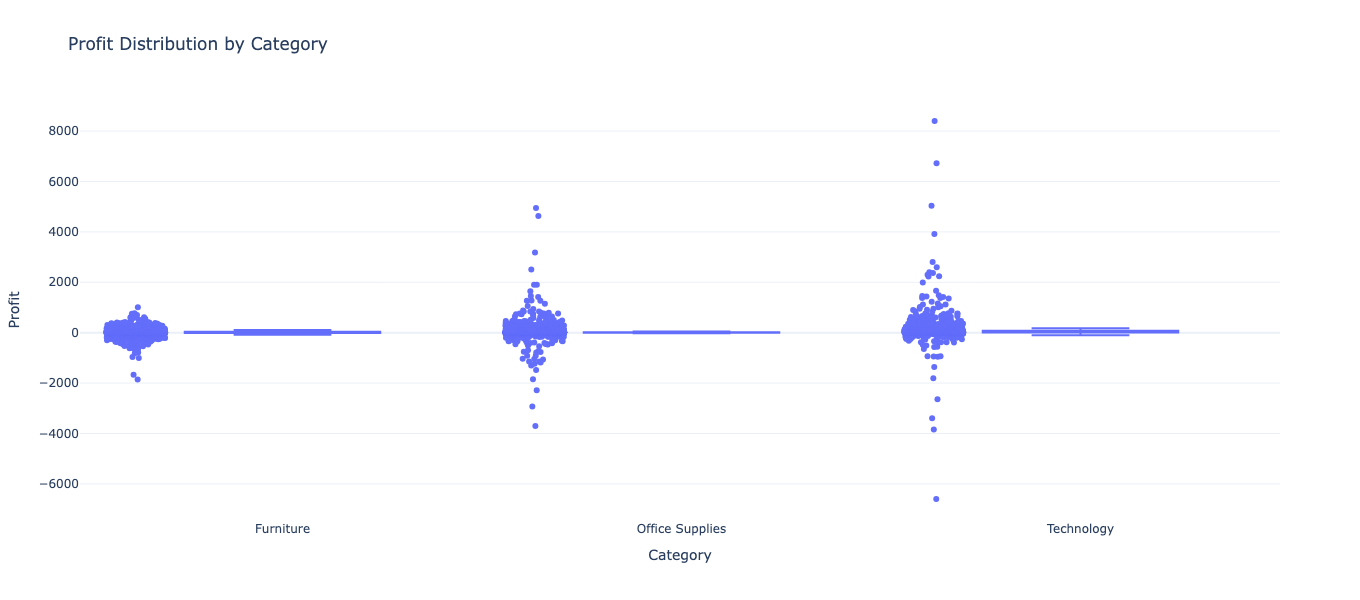

In [48]:
# plotly
fig = px.box(   df,   x="Category",  y="Profit",  title="Profit Distribution by Category", points='all')
fig.update_layout(    template="plotly_white",   width=900,   height=600)
fig.show();

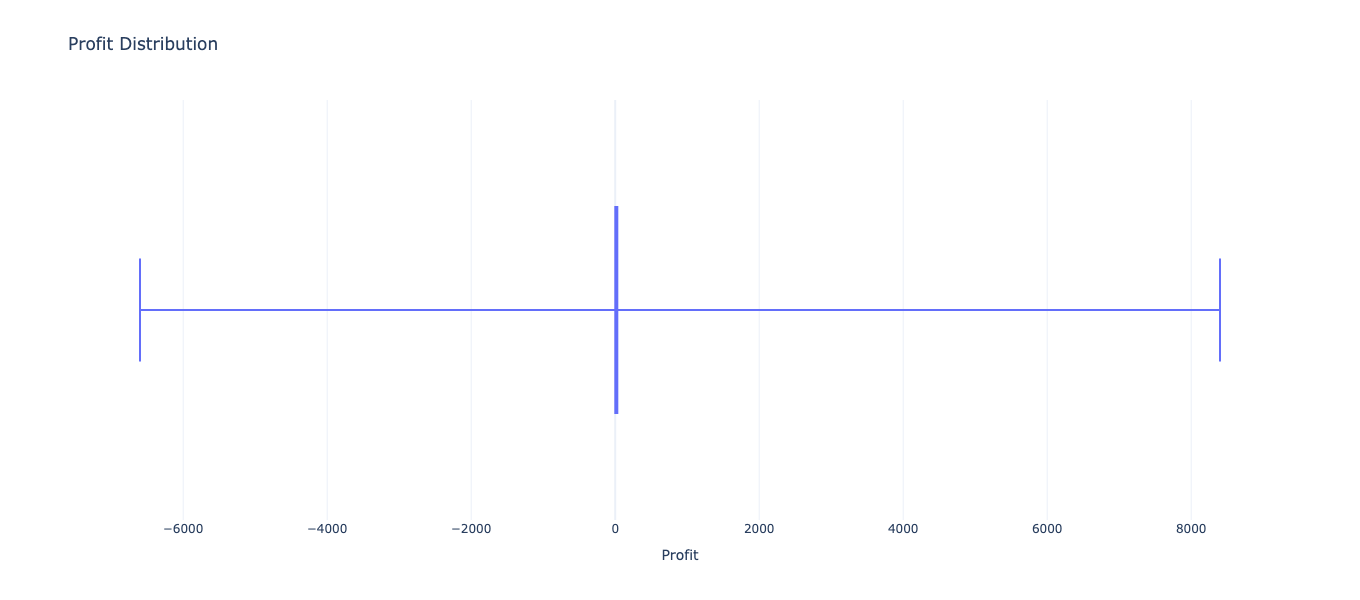

In [44]:
# plotly
fig = px.box(   df, x="Profit",  title="Profit Distribution", points=False)
fig.update_layout(    template="plotly_white",   width=900,   height=600)
fig.show();

### Remove Outliers and then plot again

/var/folders/z4/8qd93wx14xz1c9qfb_z969wc0000gn/T/ipykernel_39216/3758696781.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(   data,   labels=categories,   showfliers=False)


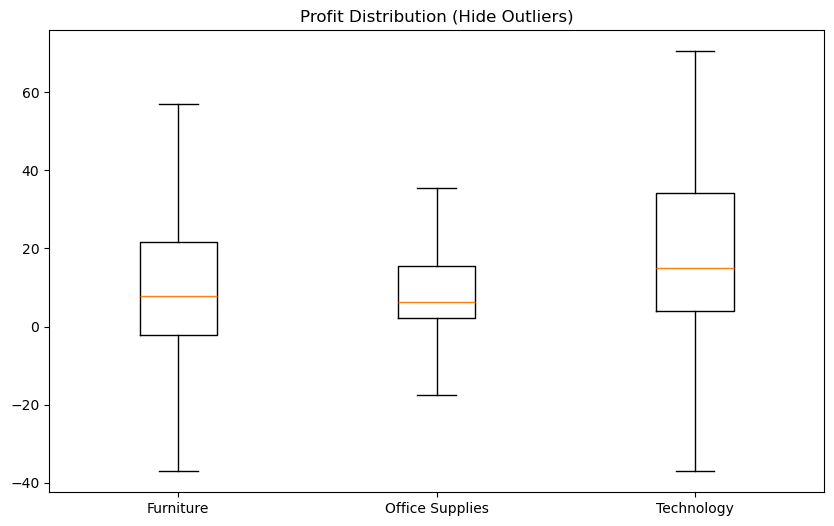

In [59]:
plt.figure(figsize=(10,6))
plt.boxplot(   data,   labels=categories,   showfliers=False)
plt.title("Profit Distribution (Hide Outliers)")
plt.show()

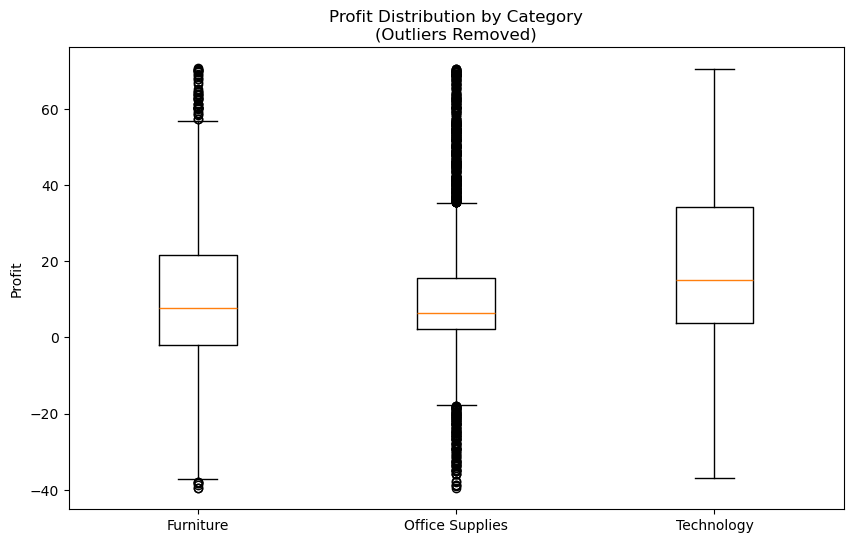

In [58]:
profit_clean = remove_outliers_iqr(df, "Profit")
categories = profit_clean["Category"].unique()
data = [ profit_clean[ profit_clean["Category"] == c ]["Profit"]  for c in categories]
plt.figure(figsize=(10,6))
plt.boxplot(   data,  tick_labels=categories)
plt.title(   "Profit Distribution by Category\n(Outliers Removed)")
plt.ylabel("Profit")
plt.show();

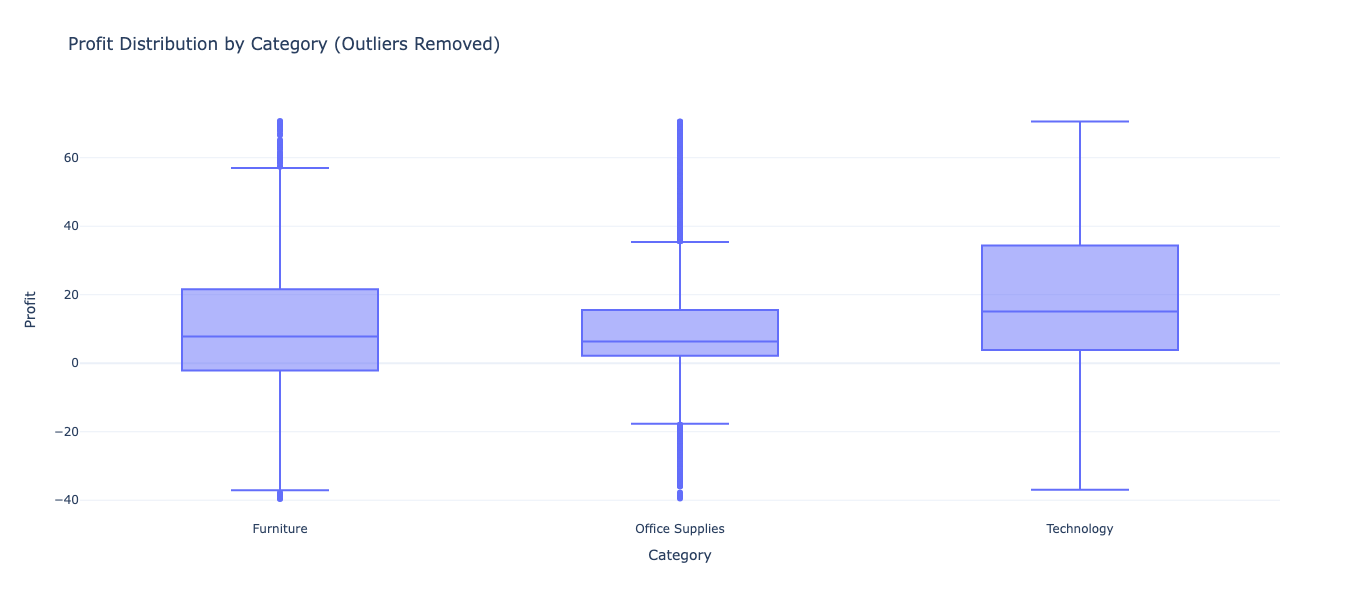

In [56]:
profit_clean = remove_outliers_iqr(df, "Profit")
fig = px.box(  profit_clean,  x="Category",  y="Profit",   title="Profit Distribution by Category (Outliers Removed)")
fig.update_layout(    template="plotly_white",   width=1000,   height=600)
fig.show();

## Pie Chart : Sales Share by  Category
- Tableau
    - Color - Category
    - Angle - Sales : sum(Sales)
- Plotly
- 

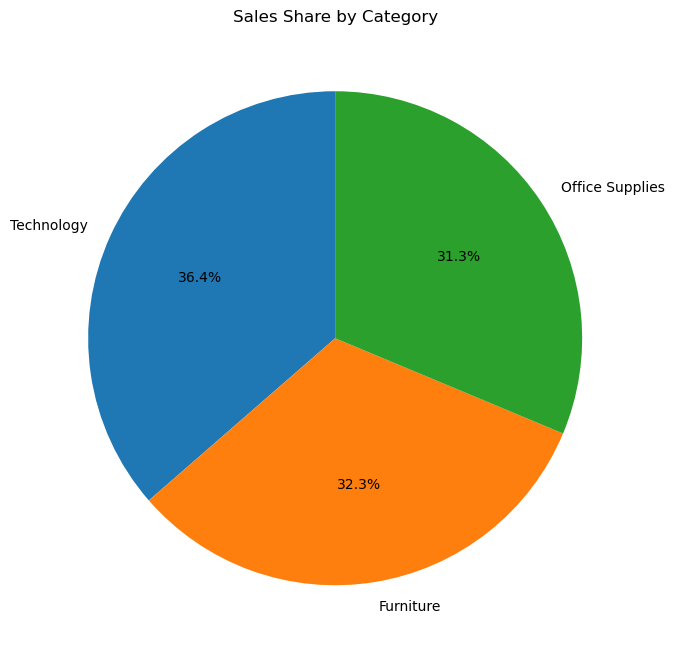

In [49]:
#mpl
category_sales = ( df.groupby("Category")["Sales"].sum().sort_values(ascending=False))
plt.figure(figsize=(7,7))
plt.pie(category_sales, labels=category_sales.index,  autopct="%1.1f%%", startangle=90)
plt.title("Sales Share by Category")
plt.tight_layout()
plt.show();

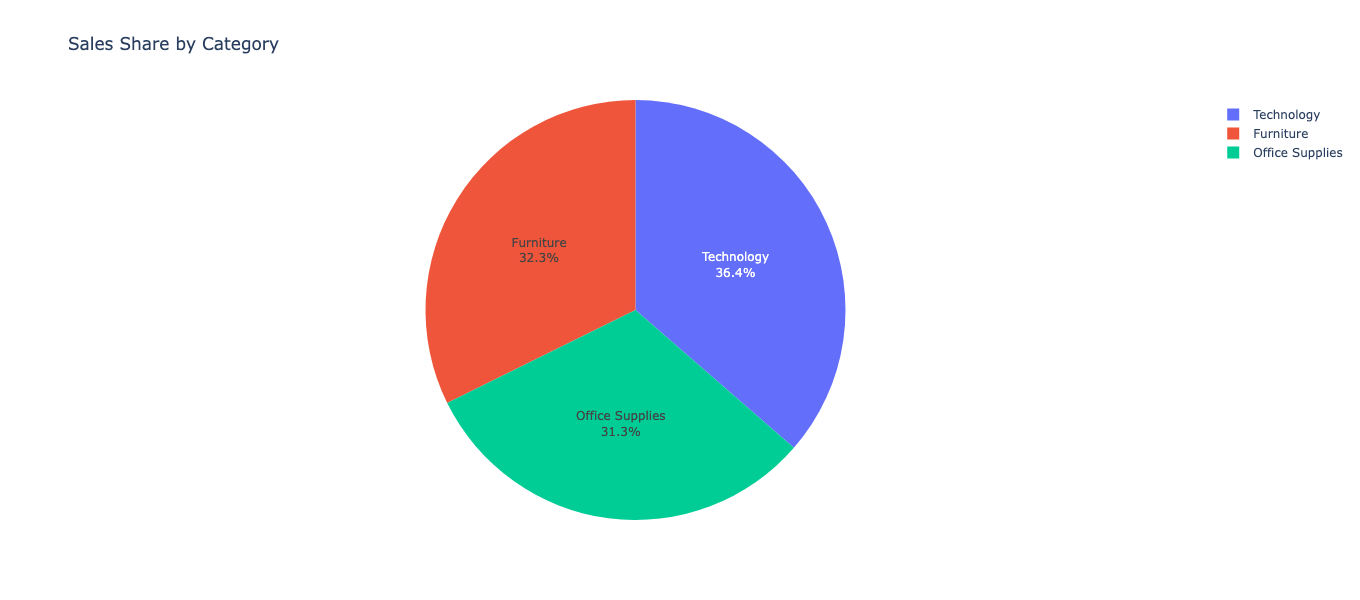

In [50]:
# plotly
category_sales_plotly = category_sales.reset_index()
fig = px.pie( category_sales_plotly,  names="Category",  values="Sales",  title="Sales Share by Category")
fig.update_traces(    textinfo="label+percent")
fig.update_layout(  template="plotly_white",  width=800,   height=600)
fig.show();

## Stacked Bar Chart : Sales by Region : Category
- Tableau
    - Columns - Region
    - Rows - Sales
    - Color - Category 

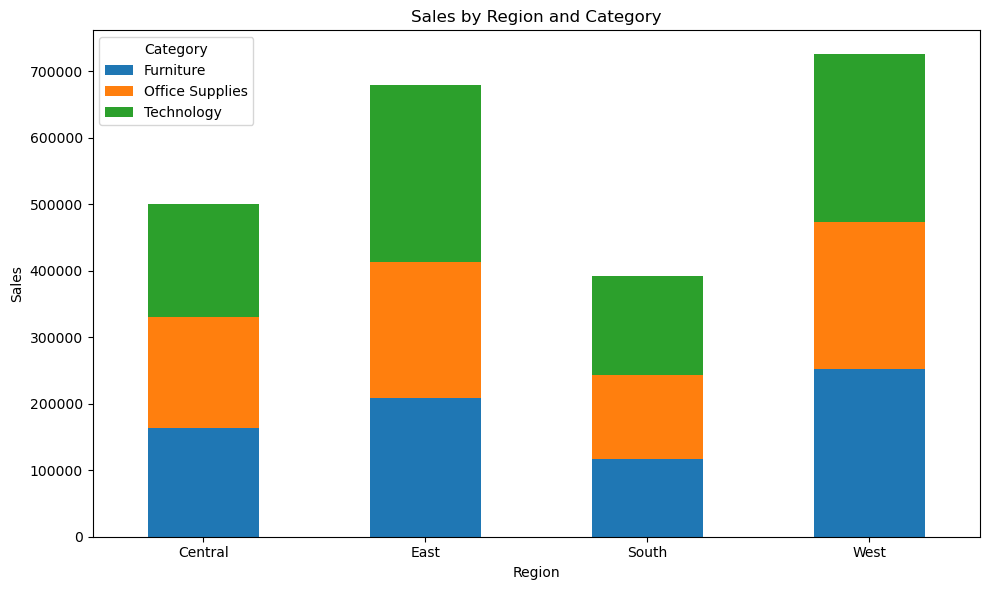

In [51]:
# mpl
stacked_data = ( df.groupby(["Region", "Category"])["Sales"].sum().unstack())
ax = stacked_data.plot( kind="bar", stacked=True, figsize=(10,6))
plt.title("Sales by Region and Category")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show();

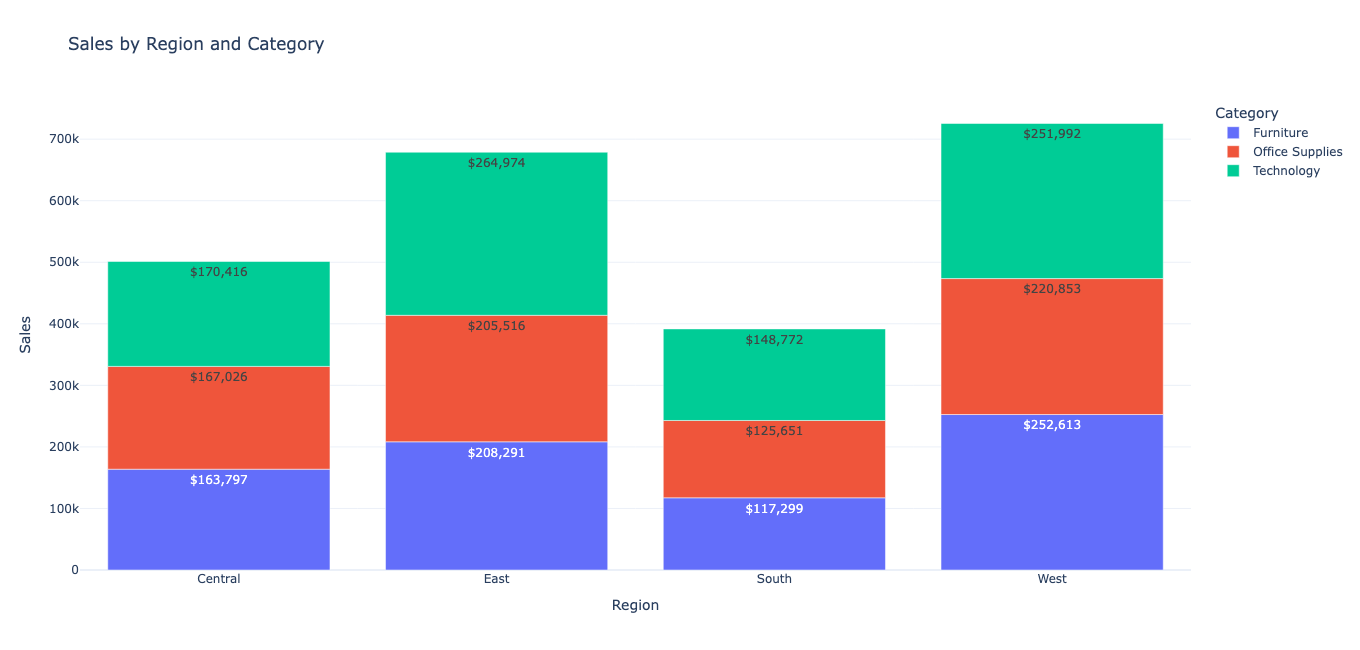

In [52]:
# plotly
stacked_plotly = ( df.groupby(["Region", "Category"])["Sales"].sum().reset_index())
fig = px.bar( stacked_plotly,  x="Region", y="Sales", color="Category", text="Sales",title="Sales by Region and Category")
fig.update_traces( texttemplate="$%{text:,.0f}",  textposition="inside")
fig.update_layout( template="plotly_white", width=1100,height=650)
fig.show();